In [379]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import os
import numpy as np



#loading the mobilenetv2 model
from models.imagenet import mobilenetv2
model = mobilenetv2()
dummy_input = torch.randn(1, 3, 1056, 320)

#wrapping mobilenetv2 as the encoder and loading its pretrained weights
class MobileNetV2Encoder(torch.nn.Module):
    def __init__(self, pretrained_path=None):
        super().__init__()
        base_model = mobilenetv2()
        if pretrained_path:
            base_model.load_state_dict(torch.load(pretrained_path))
        self.features = base_model.features
        self.skip_indices = [3, 6, 13, 17]

    def forward(self, x):
        skip_connections = []
        for idx, layer in enumerate(self.features):
            x = layer(x)
            if idx in self.skip_indices:
                skip_connections.append(x)
        return x, skip_connections



encoder = MobileNetV2Encoder(pretrained_path='pretrained/mobilenetv2-c5e733a8.pth')
encoder.eval()

#runs the encoder on dummy_input to get skip channel sizes
with torch.no_grad():
    final_output, skips = encoder(dummy_input)

c = [skip.shape[1] for skip in skips]
print("Skip channels:", c)


Skip channels: [24, 32, 96, 320]


In [380]:
print(f"Final encoder output: {final_output.shape}")
c=[]
for i, skip in enumerate(skips):
    print(f"Skip connection {i+1}: {skip.shape}")
    c.append(skip.shape[1])

intermediate_outputs = {}

def get_activation(name):
    def hook(model, input, output):
        intermediate_outputs[name] = output.detach()
    return hook

# Register hooks on key layers
# Inspect the model first to identify layer names
print(model)

# Example: Register hooks (adjust layer names based on actual architecture)
model.features[3].register_forward_hook(get_activation('layer1'))
model.features[6].register_forward_hook(get_activation('layer2'))
model.features[13].register_forward_hook(get_activation('layer3'))
model.features[17].register_forward_hook(get_activation('layer4'))

# Forward pass
with torch.no_grad():
    output = model(dummy_input)

# Print intermediate layer dimensions
for name, feature_map in intermediate_outputs.items():
    print(f"{name}: {feature_map.shape}")

Final encoder output: torch.Size([1, 320, 33, 10])
Skip connection 1: torch.Size([1, 24, 264, 80])
Skip connection 2: torch.Size([1, 32, 132, 40])
Skip connection 3: torch.Size([1, 96, 66, 20])
Skip connection 4: torch.Size([1, 320, 33, 10])
MobileNetV2(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
        (3): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedRe

In [381]:
class MyBottleNeck(nn.Module):
    def __init__(self, input, output, exp_factor=6):
        super(MyBottleNeck, self).__init__()
        hidden_dim=input*exp_factor
        self.res_available = (input == output)
        self.conv = nn.Sequential(
            #pointvise conv
            nn.Conv2d(input, hidden_dim, 1, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),

            #DSC
            nn.Conv2d(hidden_dim, hidden_dim, 3, padding=1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),

            #linear
            nn.Conv2d(hidden_dim, output, 1, bias=False),
            nn.BatchNorm2d(output),
        )

    def forward(self, x):
        if self.res_available :
            return x + self.conv(x)
        else:
            return self.conv(x)

In [382]:
class MyDecoderBlock_D1(nn.Module):
    def __init__(self, input_chan, output_chan, skip_chan):
        super(MyDecoderBlock_D1, self).__init__()
        self.pixel_shuffle = nn.PixelShuffle(upscale_factor=2)
        self.bottle_neck1 = MyBottleNeck(input=(input_chan+skip_chan)//4, output=output_chan)
        self.bottle_neck2 = MyBottleNeck(input=output_chan, output=output_chan)
        self.bottle_neck3 = MyBottleNeck(input=output_chan, output=output_chan)
        self.bottle_neck4 = MyBottleNeck(input=output_chan, output=output_chan)

    def forward(self, x, skip_tensor):
        x = torch.cat([x, skip_tensor], dim=1)
        print(f"Shape after concatenation: {x.shape}")
        x = self.pixel_shuffle(x)
        print(f"Shape after pixel shuffle: {x.shape}")
        x = self.bottle_neck1(x)
        x = self.bottle_neck2(x)
        x = self.bottle_neck3(x)
        x = self.bottle_neck4(x)
        return x
    


In [383]:
with torch.no_grad():
    encoder_output, skip_connections = encoder(dummy_input)
skip_for_D1 = skip_connections[-1]
decoder_block_D1 = MyDecoderBlock_D1(input_chan=320, output_chan=96, skip_chan=skip_for_D1.shape[1])

print("Before forward:")
print(f"Encoder output shape: {encoder_output.shape}")
print(f"Skip connection shape: {skip_for_D1.shape}")
output_D1 = decoder_block_D1(encoder_output, skip_for_D1)
print("After forward:")
print(f"Output shape: {output_D1.shape}")


Before forward:
Encoder output shape: torch.Size([1, 320, 33, 10])
Skip connection shape: torch.Size([1, 320, 33, 10])
Shape after concatenation: torch.Size([1, 640, 33, 10])
Shape after pixel shuffle: torch.Size([1, 160, 66, 20])
After forward:
Output shape: torch.Size([1, 96, 66, 20])


In [384]:

class MyDecoderBlock_D2(nn.Module):
    def __init__(self, input_chan, output_chan, skip_chan):
        super(MyDecoderBlock_D2, self).__init__()
        self.pixel_shuffle = nn.PixelShuffle(upscale_factor=2)
        self.bottle_neck1 = MyBottleNeck(input=(input_chan + skip_chan)//4, output=output_chan)
        self.bottle_neck2 = MyBottleNeck(input=output_chan, output=output_chan)
        self.bottle_neck3 = MyBottleNeck(input=output_chan, output=output_chan)

    def forward(self, x, skip_tensor):
        print(f'[D2] x shape: {x.shape}, skip shape: {skip_tensor.shape}')

        # if x.shape[2:] != skip_tensor.shape[2:]:
        #     if x.shape[2] < skip_tensor.shape[2]:
        #         x = F.interpolate(x, size=skip_tensor.shape[2:], mode='bilinear', align_corners=False)
        #     else:
        #         skip_tensor = F.interpolate(skip_tensor, size=x.shape[2:], mode='bilinear', align_corners=False)

        x = torch.cat([x, skip_tensor], dim=1)
        print(f"Shape after concatenation: {x.shape}")
        x = self.pixel_shuffle(x)
        print(f"Shape after pixel shuffle: {x.shape}")
        x = self.bottle_neck1(x)
        x = self.bottle_neck2(x)
        x = self.bottle_neck3(x)
        return x         



In [385]:
with torch.no_grad():
    encoder_output, skip_connections = encoder(dummy_input)

skip_for_D2 = skip_connections[-2]
decoder_block_D2 = MyDecoderBlock_D2(input_chan=96, output_chan=32, skip_chan=skip_for_D2.shape[1])  

print("Before forward D2:")
print(f"Input tensor shape: {output_D1.shape}")  # output of D1 is input to D2
print(f"Skip connection shape: {skip_for_D2.shape}")

output_D2 = decoder_block_D2(output_D1, skip_for_D2)

print("After forward D2:")
print(f"Output shape: {output_D2.shape}")


Before forward D2:
Input tensor shape: torch.Size([1, 96, 66, 20])
Skip connection shape: torch.Size([1, 96, 66, 20])
[D2] x shape: torch.Size([1, 96, 66, 20]), skip shape: torch.Size([1, 96, 66, 20])
Shape after concatenation: torch.Size([1, 192, 66, 20])
Shape after pixel shuffle: torch.Size([1, 48, 132, 40])
After forward D2:
Output shape: torch.Size([1, 32, 132, 40])


In [386]:
class MyDecoderBlock_D3(nn.Module):
    def __init__(self, input_chan, output_chan, skip_chan):
        super(MyDecoderBlock_D3, self).__init__()
        self.pixel_shuffle = nn.PixelShuffle(upscale_factor=2)
        self.bottle_neck1 = MyBottleNeck(input=(input_chan + skip_chan)//4, output=output_chan)
        self.bottle_neck2 = MyBottleNeck(input=output_chan, output=output_chan)
        self.bottle_neck3 = MyBottleNeck(input=output_chan, output=output_chan)

    def forward(self, x, skip_tensor):
        x = torch.cat([x, skip_tensor], dim=1)
        print(f"Shape after concatenation: {x.shape}")
        x = self.pixel_shuffle(x)
        print(f"Shape after pixel shuffle: {x.shape}")
        x = self.bottle_neck1(x)
        x = self.bottle_neck2(x)
        x = self.bottle_neck3(x)
        return x         


In [387]:
with torch.no_grad():
    encoder_output, skip_connections = encoder(dummy_input)

skip_for_D3 = skip_connections[-3]
decoder_block_D3 = MyDecoderBlock_D3(input_chan=32, output_chan=24, skip_chan=skip_for_D3.shape[1])  

print("Before forward D3:")
print(f"Input tensor shape: {output_D2.shape}")  # output of D1 is input to D2
print(f"Skip connection shape: {skip_for_D3.shape}")

output_D3 = decoder_block_D3(output_D2, skip_for_D3)

print("After forward D3:")
print(f"Output shape: {output_D3.shape}")


Before forward D3:
Input tensor shape: torch.Size([1, 32, 132, 40])
Skip connection shape: torch.Size([1, 32, 132, 40])
Shape after concatenation: torch.Size([1, 64, 132, 40])
Shape after pixel shuffle: torch.Size([1, 16, 264, 80])
After forward D3:
Output shape: torch.Size([1, 24, 264, 80])


In [388]:
class MyDecoderBlock_D4(nn.Module):
    def __init__(self, input_chan, output_chan, skip_chan):
        super(MyDecoderBlock_D4, self).__init__()
        self.pixel_shuffle = nn.PixelShuffle(upscale_factor=4)
        self.bottle_neck1 = MyBottleNeck(input=(input_chan + skip_chan)//16, output=output_chan)
        self.bottle_neck2 = MyBottleNeck(input=output_chan, output=output_chan)

    def forward(self, x, skip_tensor):
        x = torch.cat([x, skip_tensor], dim=1)
        print(f"Shape after concatenation: {x.shape}")
        x = self.pixel_shuffle(x)
        print(f"Shape after pixel shuffle: {x.shape}")
        x = self.bottle_neck1(x)
        x = self.bottle_neck2(x)
        return x         



In [389]:
skip_for_D4 = skip_connections[-4]

decoder_block_D4 = MyDecoderBlock_D4(input_chan=24, output_chan=8, skip_chan=skip_for_D4.shape[1])

print("Before forward D4:")
print(f"Input tensor shape: {output_D3.shape}")  # output of D3 is input to D4
print(f"Skip connection shape: {skip_for_D4.shape}")

output_D4 = decoder_block_D4(output_D3, skip_for_D4)

print("After forward D4:")
print(f"Output shape: {output_D4.shape}")


Before forward D4:
Input tensor shape: torch.Size([1, 24, 264, 80])
Skip connection shape: torch.Size([1, 24, 264, 80])
Shape after concatenation: torch.Size([1, 48, 264, 80])
Shape after pixel shuffle: torch.Size([1, 3, 1056, 320])
After forward D4:
Output shape: torch.Size([1, 8, 1056, 320])


In [390]:

class MyDecoder(nn.Module):
    def __init__(self, MyDecoderBlock_D1, MyDecoderBlock_D2, MyDecoderBlock_D3, MyDecoderBlock_D4):
        super(MyDecoder, self).__init__()
        self.block1 = MyDecoderBlock_D1(input_chan=320, output_chan=96, skip_chan=c[3])
        self.block2 = MyDecoderBlock_D2(input_chan=96, output_chan=32, skip_chan=c[2])
        self.block3 = MyDecoderBlock_D3(input_chan=32, output_chan=24, skip_chan=c[1])
        self.block4 = MyDecoderBlock_D4(input_chan=24, output_chan=8, skip_chan=c[0])
        self.depth_head = nn.Conv2d(8, 1, 1)   
        self.segmentation_head = nn.Conv2d(8, 19, 1) 

    def forward(self, x, skip1, skip2, skip3, skip4):  
        x = self.block1(x, skip1)
        x = self.block2(x, skip2)
        x = self.block3(x, skip3)
        x = self.block4(x, skip4)
        depth = self.depth_head(x)
        seg = self.segmentation_head(x)
        return depth, seg

In [391]:
decoder = MyDecoder(MyDecoderBlock_D1, MyDecoderBlock_D2, MyDecoderBlock_D3, MyDecoderBlock_D4)

In [392]:
class MyModel(nn.Module):
    def __init__(self, Encoder, Decoder):
        super().__init__()
        self.encoder = Encoder
        self.decoder = Decoder

    def forward(self, x):
        x, skips = self.encoder(x)
        return self.decoder(x, *skips[::-1]) 

In [393]:
model = MyModel(encoder, decoder)


In [394]:
# net = model
# for name, _ in net.named_modules():
#     print(name)

In [395]:
# transform = transforms.Compose([
#     transforms.Resize((1056,320)),
#     transforms.ToTensor(),
#     transforms.Normalize([0.485, 0.456, 0.406], 
#                          [0.229, 0.224, 0.225]),
# ])

# img = Image.open('ph.jpg')
# img_tensor = transform(img).unsqueeze(0)

# # Forward pass
# print(img_tensor.shape)
# output = model(img_tensor)
# print(type(output), output.shape)
# # print(output[0,0,:5,:5])  # preview output slice

In [396]:
# prediction = output.argmax(dim=1).squeeze().cpu().numpy()  # Shape: [112, 112]
# plt.figure(figsize=(6,6))
# plt.imshow(prediction, cmap='tab10')
# plt.title('Predicted Class Map')
# plt.axis('off')
# plt.show()

In [397]:
alpha = 0.25
beta = 0.75
m = 4
M = 80

def norm_log_transform(depthmap):
    depthmap_clamp = torch.clamp(depthmap, min=m, max=M)
    log_trans = torch.log(depthmap_clamp)
    log_m = torch.log(torch.tensor(m, dtype=depthmap.dtype, device=depthmap.device))
    log_M = torch.log(torch.tensor(M, dtype=depthmap.dtype, device=depthmap.device))
    g_d = ((log_trans - log_m) * M) / (log_M - log_m)
    return g_d

def berhu_loss(depthmap_grnd, depthmap_pred):
    diff = depthmap_grnd - depthmap_pred
    abs_diff = torch.abs(diff)
    c = torch.max(abs_diff).item() / 5
    loss = torch.where(abs_diff <= c, abs_diff, (diff ** 2 + c ** 2) / (2 * c))
    return loss.mean()

def depth_loss(depthmap_grnd, depthmap_pred):
    norm_depthmap_grnd = norm_log_transform(depthmap=depthmap_grnd)
    norm_depthmap_pred = norm_log_transform(depthmap=depthmap_pred)
    return berhu_loss(norm_depthmap_grnd, norm_depthmap_pred)

def segmentation_loss(logits, labels):
    criterion = nn.CrossEntropyLoss(ignore_index=-1)  # use correct ignore index as per your dataset
    loss = criterion(logits, labels)
    return loss

def total_loss(depthmap_grnds, depthmap_preds, segmentmap_grnd, segmentmap_preds):
    # Compute batch loss directly without looping over batch frequently
    loss_depth = depth_loss(depthmap_grnds, depthmap_preds)
    loss_seg = segmentation_loss(segmentmap_preds, segmentmap_grnd)
    return alpha * loss_depth + beta * loss_seg


In [398]:
class CustomDataset(Dataset):
    def __init__(self, img_dir, depthmap_dir, segmentmap_dir,
                 transform_img_dir=None,
                 transform_depthmap_dir=None,
                 transform_segmentmap_dir=None):
        self.img_dir = img_dir
        self.depthmap_dir = depthmap_dir
        self.segmentmap_dir = segmentmap_dir
        self.transform_img_dir = transform_img_dir
        self.transform_depthmap_dir = transform_depthmap_dir
        self.transform_segmentmap_dir = transform_segmentmap_dir
        self.img_dir_filenames = sorted([f for f in os.listdir(img_dir) if f.endswith('.npy')])

    def __len__(self):
        return len(self.img_dir_filenames)

    def __getitem__(self, idx):
        img_name = self.img_dir_filenames[idx]
        img_path = os.path.join(self.img_dir, img_name)
        depth_path = os.path.join(self.depthmap_dir, img_name)
        seg_path = os.path.join(self.segmentmap_dir, img_name)

        img = np.load(img_path)
        depthmap = np.load(depth_path)
        segmentmap = np.load(seg_path)

        # Convert to torch tensors
        if img.ndim == 3:
            img = torch.from_numpy(img).permute(2, 0, 1).float()
        else:
            img = torch.from_numpy(img).float()
        depthmap = torch.from_numpy(depthmap).float()
        segmentmap = torch.from_numpy(segmentmap).long()

        # Return without additional transform for now
        return img, depthmap, segmentmap


train_img_dir = './data/train/image'
train_depthmap_dir = './data/train/depth'
train_segmentmap_dir = './data/train/label'

train_Dataset = CustomDataset(train_img_dir, train_depthmap_dir, train_segmentmap_dir)
train_Loader = DataLoader(train_Dataset, batch_size=4, shuffle=True, num_workers=4)


In [399]:
# NOTE 

#To train the CNN on KITTI dataset, we first downsample
#RGB images from the original size of (1241, 376) to (1056,320) as the model input, while resolutions of the depth maps
#and semantic segmentation outputs of decoder blocks D1~D4
#are (66, 20), (132, 40), (264, 80), and (528, 160), respectively.
#For performance evaluation, we upsample all the predicted
#depth maps back to (1241, 376) i.e. to the orignal resolution


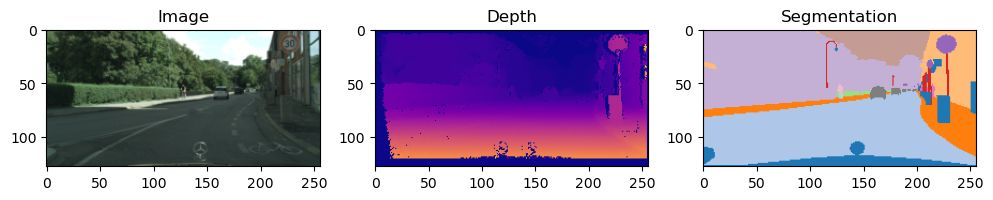

In [400]:
import matplotlib.pyplot as plt

def show_sample(img, depth, seg):
    img = img.detach().cpu()
    depth = depth.detach().cpu()
    seg = seg.detach().cpu()

    plt.figure(figsize=(12,4))

    # Image
    plt.subplot(1,3,1)
    plt.title('Image')
    plt.imshow(img.permute(1,2,0).numpy())

    # Depth
    plt.subplot(1,3,2)
    plt.title('Depth')
    plt.imshow(depth.squeeze().numpy(), cmap='plasma')

    # Segmentation
    plt.subplot(1,3,3)
    plt.title('Segmentation')
    plt.imshow(seg.squeeze().numpy(), cmap='tab20')

    plt.show()

# Show one sample
for imgs, depths, segs in train_Loader:
    show_sample(imgs[0], depths[0], segs[0])

    break


In [401]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import os
import numpy as np
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

device = torch.device('cpu')
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler = StepLR(optimizer, step_size=1, gamma=0.90)

epochs = 20
itr = 1000

model.train()

for epoch in range(epochs):
    running_loss = 0.0
    for i, (imgs, depths, segs) in enumerate(train_Loader):
        if i >= itr:
            break
        imgs = imgs.to(device)
        depths = depths.to(device).squeeze(-1)
        segs = segs.to(device)

        optimizer.zero_grad(set_to_none=True)
        pred_depths, pred_segs = model(imgs)
        pred_depths = pred_depths.squeeze(1)

        loss_total = total_loss(depths, pred_depths, segs, pred_segs)
        loss_total.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Check gradients for NaNs/Infs
        for name, param in model.named_parameters():
            if param.grad is not None:
                if torch.isnan(param.grad).any():
                    raise ValueError(f"NaN gradient detected in {name}")
                if torch.isinf(param.grad).any():
                    raise ValueError(f"Inf gradient detected in {name}")

        optimizer.step()

        running_loss += loss_total.item()

    avg_loss = running_loss / itr
    print(f"Epoch {epoch+1}/{epochs} | Avg Loss: {avg_loss:.4f}")
    scheduler.step()
    print(f"Learning rate after epoch {epoch+1}: {optimizer.param_groups[0]['lr']}")

Shape after concatenation: torch.Size([4, 640, 4, 8])
Shape after pixel shuffle: torch.Size([4, 160, 8, 16])
[D2] x shape: torch.Size([4, 96, 8, 16]), skip shape: torch.Size([4, 96, 8, 16])
Shape after concatenation: torch.Size([4, 192, 8, 16])
Shape after pixel shuffle: torch.Size([4, 48, 16, 32])
Shape after concatenation: torch.Size([4, 64, 16, 32])
Shape after pixel shuffle: torch.Size([4, 16, 32, 64])
Shape after concatenation: torch.Size([4, 48, 32, 64])
Shape after pixel shuffle: torch.Size([4, 3, 128, 256])


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
# import torch
# import torch.nn.functional as F
# from torch.optim.lr_scheduler import StepLR

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print("Using device:", device)
# model = model.to(device)

# optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
# scheduler = StepLR(optimizer, step_size=1, gamma=0.90)

# def tensor_info(name, t):
#     try:
#         return f"{name}: device={t.device} dtype={t.dtype} shape={tuple(t.shape)} min={float(torch.min(t))} max={float(torch.max(t))}"
#     except Exception as e:
#         return f"{name}: cannot show stats ({e})"

# for epoch in range(epochs):
#     running_loss = 0.0
#     for i, (imgs, depths, segs) in enumerate(train_Loader):
#         if i >= itr:
#             break

#         # Move to device and ensure correct dtypes
#         imgs = imgs.to(device, non_blocking=True)
#         depths = depths.to(device, non_blocking=True)
#         segs = segs.to(device, non_blocking=True)

#         # If depths has channel dim [B,1,H,W], make [B,H,W] or [B,H,W] as expected
#         if depths.dim() == 4 and depths.size(1) == 1:
#             depths = depths.squeeze(1)
#         elif depths.dim() == 4 and depths.size(1) != 1:
#             # if channel is at last dim, adapt accordingly - but usually it's [B,1,H,W]
#             pass

#         # Segmentation targets must be long for cross_entropy
#         if segs.dtype != torch.long:
#             segs = segs.long()

#         optimizer.zero_grad(set_to_none=True)

#         pred_depths, pred_segs = model(imgs)   # assumed outputs: [B,1,H,W], [B,C,H,W] or similar
#         # normalize shapes
#         if pred_depths.dim() == 4 and pred_depths.size(1) == 1:
#             pred_depths = pred_depths.squeeze(1)

#         # Quick diagnostics
#         print("--- batch", i, "epoch", epoch, "---")
#         print(tensor_info("imgs", imgs))
#         print(tensor_info("depths", depths))
#         print(tensor_info("pred_depths", pred_depths))
#         print(tensor_info("pred_segs", pred_segs))
#         print(tensor_info("segs", segs))

#         # Validate seg labels for cross_entropy
#         if pred_segs.dim() != 4:
#             raise RuntimeError("pred_segs should be a 4D tensor [B,C,H,W]")

#         n_classes = pred_segs.size(1)
#         seg_min = int(torch.min(segs).item())
#         seg_max = int(torch.max(segs).item())
#         if seg_min < 0 or seg_max >= n_classes:
#             print(f"Label range invalid for cross_entropy: min={seg_min}, max={seg_max}, n_classes={n_classes}")
#             # If some labels are -1 and meant to be ignore_index:
#             # pass ignore_index here or remap labels. Example below uses ignore_index = 255
#             # You can choose an appropriate ignore_index if you have void labels.
#             # For now raise so you can inspect the labels.
#             raise ValueError("Segmentation labels out of valid range for the model's number of classes")

#         # OPTIONAL: check for NaNs/Infs in preds
#         if torch.isnan(pred_depths).any() or torch.isinf(pred_depths).any():
#             raise ValueError("NaN/Inf in pred_depths")

#         if torch.isnan(pred_segs).any() or torch.isinf(pred_segs).any():
#             raise ValueError("NaN/Inf in pred_segs")

#         # Compute loss (your total_loss function)
#         loss_total = total_loss(depths, pred_depths, segs, pred_segs)

#         # check loss value before backward
#         if torch.isnan(loss_total) or torch.isinf(loss_total):
#             raise ValueError("Loss is NaN or Inf before backward")

#         # Backprop and step with cuda sync for better stack traces
#         try:
#             loss_total.backward()
#             # optional: check grads for NaN/inf
#             for name, p in model.named_parameters():
#                 if p.grad is not None:
#                     if torch.isnan(p.grad).any() or torch.isinf(p.grad).any():
#                         raise ValueError(f"Grad NaN/Inf in {name}")
#             # synchronize and step
#             if device.type == 'cuda':
#                 torch.cuda.synchronize()
#             optimizer.step()
#         except Exception as e:
#             # Try to give more helpful info and re-raise
#             if device.type == 'cuda':
#                 torch.cuda.synchronize()
#             print("Exception during backward/step:", e)
#             # print relevant tensors to help debug
#             print("loss_total:", loss_total.item() if isinstance(loss_total, torch.Tensor) else loss_total)
#             print("pred_segs min/max:", torch.min(pred_segs).item(), torch.max(pred_segs).item())
#             print("segs min/max:", torch.min(segs).item(), torch.max(segs).item())
#             raise

#         running_loss += loss_total.item()
#     avg_loss = running_loss / (i+1)
#     print(f"Epoch {epoch+1}/{epochs} | Avg Loss: {avg_loss:.6f}")
#     scheduler.step()
#     print("LR:", optimizer.param_groups[0]['lr'])


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import os
import numpy as np
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# Dummy MobileNetV2 import (replace with your actual import)
try:
    from models.imagenet import mobilenetv2
except:
    # Fallback for testing - create dummy encoder
    class DummyEncoder(nn.Module):
        def __init__(self):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 24, 3, stride=2, padding=1),
                nn.Conv2d(24, 32, 3, stride=2, padding=1),
                nn.Conv2d(32, 96, 3, stride=2, padding=1),
                nn.Conv2d(96, 320, 3, stride=2, padding=1)
            )
        def forward(self, x):
            skips = []
            for i, layer in enumerate(self.features):
                x = layer(x)
                if i in [0, 1, 2, 3]:
                    skips.append(x)
            return x, skips
    mobilenetv2 = DummyEncoder

# 1. ENCODER
class MobileNetV2Encoder(nn.Module):
    def __init__(self, pretrained_path=None):
        super().__init__()
        base_model = mobilenetv2()
        if pretrained_path and os.path.exists(pretrained_path):
            base_model.load_state_dict(torch.load(pretrained_path, map_location='cpu'))
        self.features = base_model.features if hasattr(base_model, 'features') else base_model
        self.skip_indices = [3, 6, 13, 17]

    def forward(self, x):
        skip_connections = []
        for idx, layer in enumerate(self.features):
            x = layer(x)
            if idx in self.skip_indices:
                skip_connections.append(x)
        return x, skip_connections

# 2. BOTTLENECK BLOCK
class MyBottleNeck(nn.Module):
    def __init__(self, input_ch, output_ch, exp_factor=6):
        super().__init__()
        hidden_dim = input_ch * exp_factor
        self.residual = (input_ch == output_ch)
        self.conv = nn.Sequential(
            nn.Conv2d(input_ch, hidden_dim, 1, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),
            nn.Conv2d(hidden_dim, hidden_dim, 3, padding=1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),
            nn.Conv2d(hidden_dim, output_ch, 1, bias=False),
            nn.BatchNorm2d(output_ch),
        )

    def forward(self, x):
        out = self.conv(x)
        if self.residual:
            out = out + x
        return F.relu6(out)

# 3. DECODER BLOCKS
class MyDecoderBlock_D1(nn.Module):
    def __init__(self, input_chan, output_chan, skip_chan):
        super().__init__()
        total_chan = input_chan + skip_chan
        self.pre_shuffle = nn.Conv2d(total_chan, 4*output_chan, 1) if total_chan % 4 != 0 else None
        self.pixel_shuffle = nn.PixelShuffle(2)
        self.bottlenecks = nn.ModuleList([
            MyBottleNeck(4*output_chan if self.pre_shuffle else total_chan//4, output_chan),
            MyBottleNeck(output_chan, output_chan),
            MyBottleNeck(output_chan, output_chan),
            MyBottleNeck(output_chan, output_chan)
        ])

    def forward(self, x, skip):
        x = torch.cat([x, skip], dim=1)
        if self.pre_shuffle:
            x = self.pre_shuffle(x)
        x = self.pixel_shuffle(x)
        for bn in self.bottlenecks:
            x = bn(x)
        return x

class MyDecoderBlock_D2(nn.Module):
    def __init__(self, input_chan, output_chan, skip_chan):
        super().__init__()
        total_chan = input_chan + skip_chan
        self.pre_shuffle = nn.Conv2d(total_chan, 4*output_chan, 1) if total_chan % 4 != 0 else None
        self.pixel_shuffle = nn.PixelShuffle(2)
        self.bottlenecks = nn.ModuleList([
            MyBottleNeck(4*output_chan if self.pre_shuffle else total_chan//4, output_chan),
            MyBottleNeck(output_chan, output_chan),
            MyBottleNeck(output_chan, output_chan)
        ])

    def forward(self, x, skip):
        x = torch.cat([x, skip], dim=1)
        if self.pre_shuffle:
            x = self.pre_shuffle(x)
        x = self.pixel_shuffle(x)
        for bn in self.bottlenecks:
            x = bn(x)
        return x

class MyDecoderBlock_D3(MyDecoderBlock_D2):  # Same as D2
    def __init__(self, input_chan, output_chan, skip_chan):
        super().__init__(input_chan, output_chan, skip_chan)

class MyDecoderBlock_D4(nn.Module):
    def __init__(self, input_chan, output_chan, skip_chan):
        super().__init__()
        total_chan = input_chan + skip_chan
        self.pre_shuffle = nn.Conv2d(total_chan, 16*output_chan, 1) if total_chan % 16 != 0 else None
        self.pixel_shuffle = nn.PixelShuffle(4)
        self.bottlenecks = nn.ModuleList([
            MyBottleNeck(16*output_chan if self.pre_shuffle else total_chan//16, output_chan),
            MyBottleNeck(output_chan, output_chan)
        ])

    def forward(self, x, skip):
        x = torch.cat([x, skip], dim=1)
        if self.pre_shuffle:
            x = self.pre_shuffle(x)
        x = self.pixel_shuffle(x)
        for bn in self.bottlenecks:
            x = bn(x)
        return x

# 4. DECODER
class MyDecoder(nn.Module):
    def __init__(self, skip_channels):
        super().__init__()
        self.block1 = MyDecoderBlock_D1(320, 96, skip_channels[3])
        self.block2 = MyDecoderBlock_D2(96, 32, skip_channels[2])
        self.block3 = MyDecoderBlock_D3(32, 24, skip_channels[1])
        self.block4 = MyDecoderBlock_D4(24, 8, skip_channels[0])
        self.depth_head = nn.Conv2d(8, 1, 1)
        self.seg_head = nn.Conv2d(8, 19, 1)

    def forward(self, x, skips):
        x = self.block1(x, skips[3])
        x = self.block2(x, skips[2])
        x = self.block3(x, skips[1])
        x = self.block4(x, skips[0])
        depth = self.depth_head(x)
        seg = self.seg_head(x)
        return depth, seg

# 5. FULL MODEL
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = MobileNetV2Encoder(pretrained_path='pretrained/mobilenetv2-c5e733a8.pth')
        
        # Get skip channels
        dummy_input = torch.randn(1, 3, 1056, 320)
        self.encoder.eval()
        with torch.no_grad():
            _, skips = self.encoder(dummy_input)
        skip_channels = [s.shape[1] for s in skips]
        print(f"Skip channels: {skip_channels}")
        
        self.decoder = MyDecoder(skip_channels)
        self.encoder.train()  # Back to train mode

    def forward(self, x):
        encoder_out, skips = self.encoder(x)
        return self.decoder(encoder_out, skips)

# 6. LOSS FUNCTIONS
alpha, beta = 0.25, 0.75
m, M = 4, 80

def norm_log_transform(depth):
    depth = torch.clamp(depth, min=m, max=M)
    log_depth = torch.log(depth)
    log_m = torch.log(torch.tensor(m, dtype=depth.dtype, device=depth.device))
    log_M = torch.log(torch.tensor(M, dtype=depth.dtype, device=depth.device))
    return ((log_depth - log_m) * M) / (log_M - log_m)

def berhu_loss(gt, pred):
    diff = gt - pred
    abs_diff = torch.abs(diff)
    c = torch.max(abs_diff) / 5
    loss = torch.where(abs_diff <= c, abs_diff, (diff**2 + c**2) / (2*c))
    return loss.mean()

def depth_loss(gt, pred):
    norm_gt = norm_log_transform(gt)
    norm_pred = norm_log_transform(pred)
    return berhu_loss(norm_gt, norm_pred)

def segmentation_loss(logits, labels):
    return F.cross_entropy(logits, labels, ignore_index=-1)

def total_loss(depth_gt, depth_pred, seg_gt, seg_pred):
    return alpha * depth_loss(depth_gt, depth_pred) + beta * segmentation_loss(seg_pred, seg_gt)

# 7. DATASET (update paths as needed)
class CustomDataset(Dataset):
    def __init__(self, img_dir, depth_dir, seg_dir):
        self.img_dir = img_dir
        self.depth_dir = depth_dir
        self.seg_dir = seg_dir
        self.files = sorted([f for f in os.listdir(img_dir) if f.endswith('.npy')])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img = np.load(os.path.join(self.img_dir, fname))
        depth = np.load(os.path.join(self.depth_dir, fname))
        seg = np.load(os.path.join(self.seg_dir, fname))

        if img.ndim == 3:
            img = torch.from_numpy(img).permute(2, 0, 1).float()
        else:
            img = torch.from_numpy(img).float()
        
        depth = torch.from_numpy(depth).float()
        seg = torch.from_numpy(seg).long()
        
        # Normalize image for pretrained encoder
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = (img - mean) / std
        
        return img, depth, seg

# 8. TRAINING
device = torch.device('cpu')
model = MyModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = StepLR(optimizer, step_size=5, gamma=0.9)

# Dataset (UPDATE THESE PATHS)
train_dataset = CustomDataset(
    './data/train/image',
    './data/train/depth', 
    './data/train/label'
)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)

# Training loop
model.train()
epochs = 5  # Start small
iters_per_epoch = 100

for epoch in range(epochs):
    running_loss = 0.0
    for i, (imgs, depths, segs) in enumerate(train_loader):
        if i >= iters_per_epoch:
            break
            
        imgs, depths, segs = imgs.to(device), depths.to(device), segs.to(device)
        depths = depths.squeeze(-1) if depths.dim() == 4 else depths

        optimizer.zero_grad()
        pred_depth, pred_seg = model(imgs)
        pred_depth = pred_depth.squeeze(1)
        
        loss = total_loss(depths, pred_depth, segs, pred_seg)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_loss = running_loss / iters_per_epoch
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    scheduler.step()

print("Training complete!")


Skip channels: [24, 32, 96, 320]
Epoch 1/5, Loss: 2.4714
Epoch 2/5, Loss: 2.3095
Epoch 3/5, Loss: 2.1312
Epoch 4/5, Loss: 1.9780
Epoch 5/5, Loss: 1.8402
Training complete!


Using: cuda
Skip channels: [24, 32, 96, 320]
Final encoder output: torch.Size([1, 320, 33, 10])
✅ Loaded trained model!
Predicting image.png...


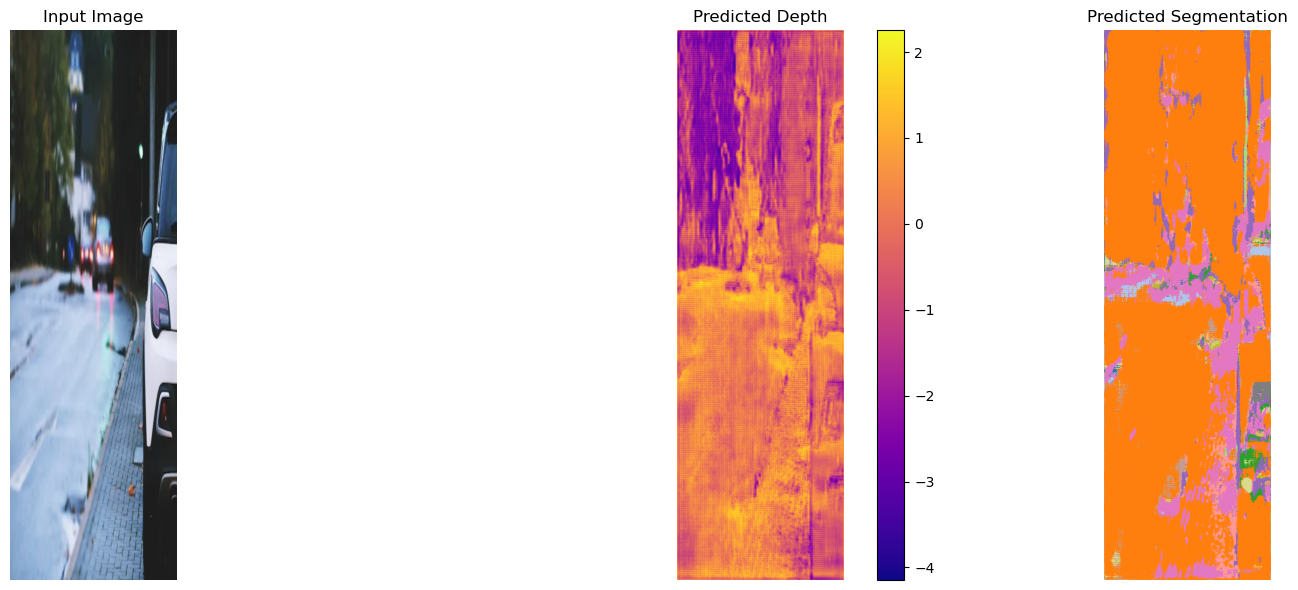

✅ DONE!
Depth range: -4.1m - 2.3m
Classes predicted: 0 to 18
Saved: single_image_result.jpg


In [21]:
# ============================================================================
# 1-IMAGE TEST - Load trained model → Predict → Visualize
# ============================================================================
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import torch
import numpy as np
import os

# 1. LOAD TRAINED MODEL
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using: {device}")

model = MyModel()
if os.path.exists('depth_seg_model.pth'):
    model.load_state_dict(torch.load('depth_seg_model.pth', map_location=device))
    print("✅ Loaded trained model!")
else:
    print("❌ Train first! Need depth_seg_model.pth")
    exit()

model.to(device).eval()

# 2. LOAD & PREDICT IMAGE
transform = transforms.Compose([
    transforms.Resize((1056, 320)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Auto-find your image
for ext in ['image.png', 'image.jpg']:
    if os.path.exists(ext):
        img_path = ext
        break
else:
    print("❌ Put image.png/image.jpg in folder!")
    exit()

img = Image.open(img_path).convert('RGB')
img_tensor = transform(img).unsqueeze(0).to(device)

print(f"Predicting {img_path}...")

# 3. INFERENCE
with torch.no_grad():
    pred_depth, pred_seg = model(img_tensor)
    pred_depth = pred_depth.squeeze().cpu().numpy()
    pred_seg = pred_seg.argmax(1).squeeze().cpu().numpy()

# 4. VISUALIZE
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_vis = ((img_tensor.squeeze(0).cpu() * torch.tensor(std).view(3,1,1) + 
           torch.tensor(mean).view(3,1,1)).clamp(0,1).permute(1,2,0).numpy())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_vis)
axes[0].set_title('Input Image')
axes[0].axis('off')

im1 = axes[1].imshow(pred_depth, cmap='plasma')
axes[1].set_title('Predicted Depth')
plt.colorbar(im1, ax=axes[1])
axes[1].axis('off')

axes[2].imshow(pred_seg.astype(np.uint8), cmap='tab20')
axes[2].set_title('Predicted Segmentation')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('single_image_result.jpg', dpi=200, bbox_inches='tight')
plt.show()

print(f"✅ DONE!")
print(f"Depth range: {pred_depth.min():.1f}m - {pred_depth.max():.1f}m")
print(f"Classes predicted: 0 to {int(pred_seg.max())}")
print("Saved: single_image_result.jpg")


Using device: cuda
Dataset size: 2975
Skip channels: [24, 32, 96, 320]
Final encoder output: torch.Size([1, 320, 33, 10])
Model created with 2.51M parameters
Epoch [1/20], Iter [100], Loss: 0.9259, Avg: 1.4558
Epoch [1/20], Iter [200], Loss: 0.6399, Avg: 1.0773
Epoch [1/20], Iter [300], Loss: 0.6541, Avg: 0.9036
Epoch [1/20], Iter [400], Loss: 0.3768, Avg: 0.8026
Epoch [1/20], Iter [500], Loss: 0.6529, Avg: 0.7368
Epoch [1/20], Iter [600], Loss: 0.2885, Avg: 0.6871
Epoch [1/20], Iter [700], Loss: 0.4574, Avg: 0.6506
Epoch 1/20 Complete | Avg Loss: 0.6379
Learning rate: 0.001000

Epoch [2/20], Iter [100], Loss: 0.6194, Avg: 0.4088
Epoch [2/20], Iter [200], Loss: 0.2958, Avg: 0.4023
Epoch [2/20], Iter [300], Loss: 0.3524, Avg: 0.3957
Epoch [2/20], Iter [400], Loss: 0.6136, Avg: 0.3978
Epoch [2/20], Iter [500], Loss: 0.2607, Avg: 0.3940
Epoch [2/20], Iter [600], Loss: 0.4145, Avg: 0.3908
Epoch [2/20], Iter [700], Loss: 0.2683, Avg: 0.3882
Epoch 2/20 Complete | Avg Loss: 0.3871
Learning ra

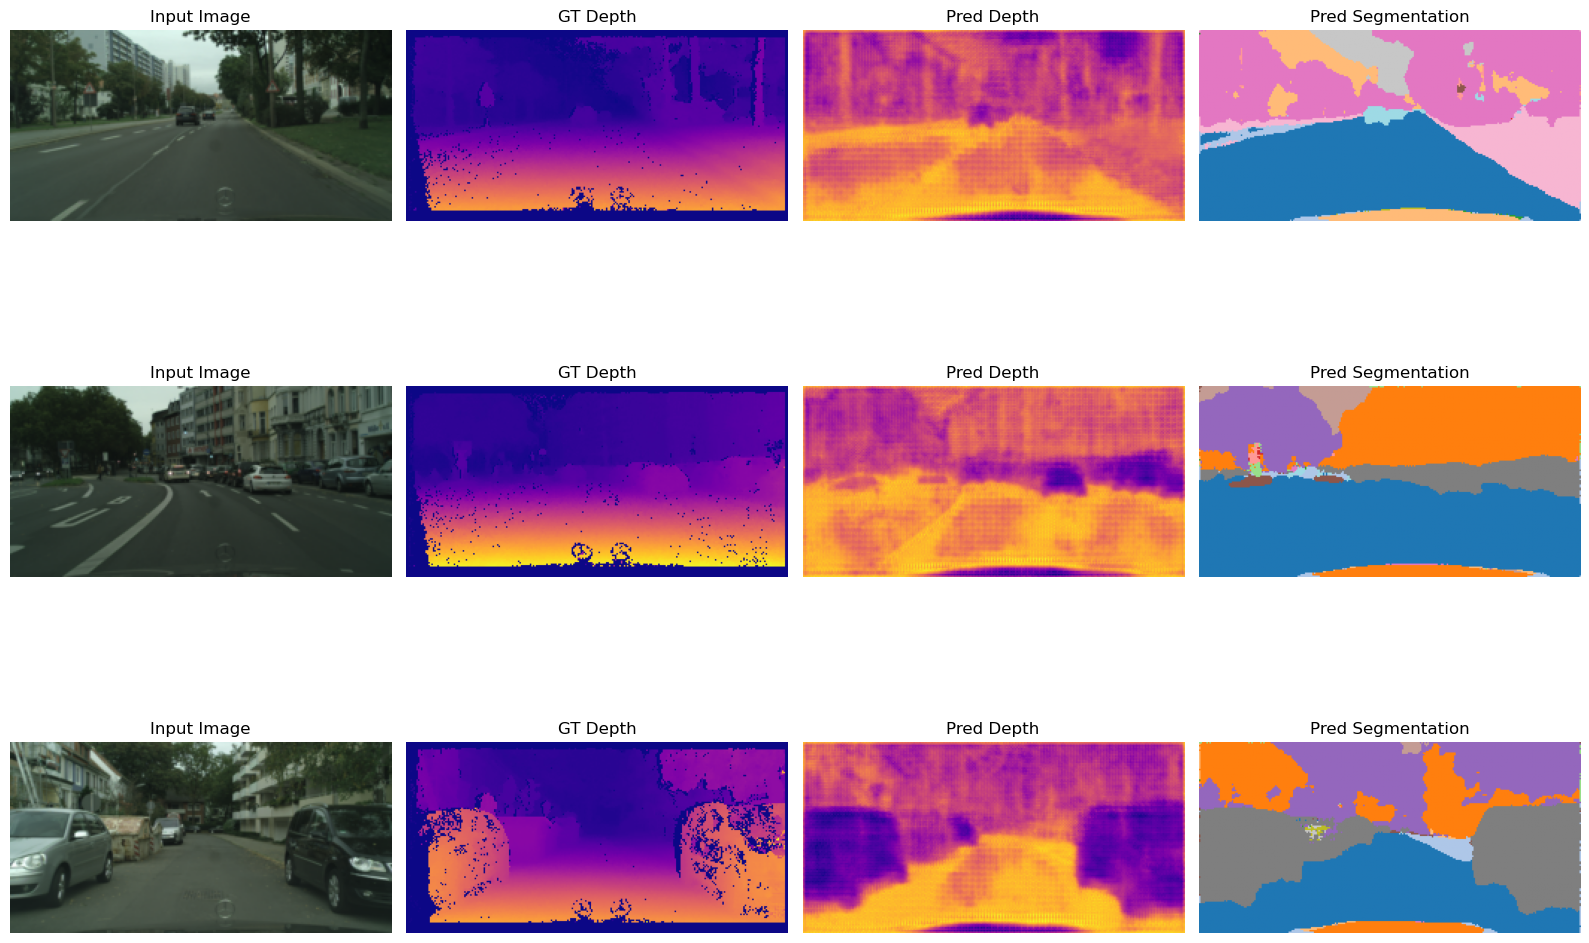

Saved predictions to 'predictions.png'


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import os
import numpy as np
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR


# ============================================================================
# ENCODER
# ============================================================================
class MobileNetV2Encoder(nn.Module):
    def __init__(self, pretrained_path=None):
        super().__init__()
        # Use torchvision's MobileNetV2 as fallback if custom model not available
        try:
            from models.imagenet import mobilenetv2
            base_model = mobilenetv2()
            if pretrained_path and os.path.exists(pretrained_path):
                base_model.load_state_dict(torch.load(pretrained_path, map_location='cpu'))
        except:
            print("Using torchvision MobileNetV2 instead")
            base_model = models.mobilenet_v2(pretrained=True)
        
        self.features = base_model.features
        self.skip_indices = [3, 6, 13, 17]

    def forward(self, x):
        skip_connections = []
        for idx, layer in enumerate(self.features):
            x = layer(x)
            if idx in self.skip_indices:
                skip_connections.append(x)
        return x, skip_connections


# ============================================================================
# GET SKIP CHANNEL DIMENSIONS
# ============================================================================
def get_skip_channels(encoder, input_size=(1, 3, 1056, 320)):
    encoder.eval()
    dummy_input = torch.randn(*input_size)
    with torch.no_grad():
        final_output, skips = encoder(dummy_input)
    
    c = [skip.shape[1] for skip in skips]
    print("Skip channels:", c)
    print(f"Final encoder output: {final_output.shape}")
    return c, final_output.shape[1]


# ============================================================================
# DECODER BLOCKS
# ============================================================================
class MyBottleNeck(nn.Module):
    def __init__(self, input_dim, output_dim, exp_factor=6):
        super(MyBottleNeck, self).__init__()
        hidden_dim = input_dim * exp_factor
        self.res_available = (input_dim == output_dim)
        self.conv = nn.Sequential(
            nn.Conv2d(input_dim, hidden_dim, 1, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),
            nn.Conv2d(hidden_dim, hidden_dim, 3, padding=1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),
            nn.Conv2d(hidden_dim, output_dim, 1, bias=False),
            nn.BatchNorm2d(output_dim),
        )

    def forward(self, x):
        if self.res_available:
            return x + self.conv(x)
        else:
            return self.conv(x)


class MyDecoderBlock(nn.Module):
    def __init__(self, input_chan, output_chan, skip_chan, upscale_factor=2, num_bottlenecks=3):
        super(MyDecoderBlock, self).__init__()
        self.upscale_factor = upscale_factor
        
        # Adjust channels to be divisible by upscale_factor^2
        total_channels = input_chan + skip_chan
        divisor = upscale_factor ** 2
        
        # Ensure divisibility
        if total_channels % divisor != 0:
            padding_channels = divisor - (total_channels % divisor)
            self.channel_adjust = nn.Conv2d(skip_chan, skip_chan + padding_channels, 1)
            total_channels += padding_channels
        else:
            self.channel_adjust = None
        
        self.pixel_shuffle = nn.PixelShuffle(upscale_factor=upscale_factor)
        
        # Bottlenecks
        bottleneck_input = total_channels // divisor
        self.bottlenecks = nn.ModuleList([
            MyBottleNeck(bottleneck_input if i == 0 else output_chan, output_chan)
            for i in range(num_bottlenecks)
        ])

    def forward(self, x, skip_tensor):
        # Spatial alignment
        if x.shape[2:] != skip_tensor.shape[2:]:
            x = F.interpolate(x, size=skip_tensor.shape[2:], mode='bilinear', align_corners=False)
        
        # Channel adjustment if needed
        if self.channel_adjust is not None:
            skip_tensor = self.channel_adjust(skip_tensor)
        
        x = torch.cat([x, skip_tensor], dim=1)
        x = self.pixel_shuffle(x)
        
        for bottleneck in self.bottlenecks:
            x = bottleneck(x)
        
        return x


# ============================================================================
# DECODER
# ============================================================================
class MyDecoder(nn.Module):
    def __init__(self, encoder_output_channels, skip_channels):
        super(MyDecoder, self).__init__()
        self.block1 = MyDecoderBlock(encoder_output_channels, 96, skip_channels[3], upscale_factor=2, num_bottlenecks=4)
        self.block2 = MyDecoderBlock(96, 32, skip_channels[2], upscale_factor=2, num_bottlenecks=3)
        self.block3 = MyDecoderBlock(32, 24, skip_channels[1], upscale_factor=2, num_bottlenecks=3)
        self.block4 = MyDecoderBlock(24, 8, skip_channels[0], upscale_factor=4, num_bottlenecks=2)
        
        self.depth_head = nn.Conv2d(8, 1, 1)
        self.segmentation_head = nn.Conv2d(8, 19, 1)

    def forward(self, x, skip1, skip2, skip3, skip4):
        x = self.block1(x, skip1)
        x = self.block2(x, skip2)
        x = self.block3(x, skip3)
        x = self.block4(x, skip4)
        depth = self.depth_head(x)
        seg = self.segmentation_head(x)
        return depth, seg


# ============================================================================
# FULL MODEL
# ============================================================================
class MyModel(nn.Module):
    def __init__(self, pretrained_encoder_path=None):
        super().__init__()
        self.encoder = MobileNetV2Encoder(pretrained_encoder_path)
        
        # Get skip channels dynamically
        skip_channels, encoder_output_channels = get_skip_channels(self.encoder)
        
        self.decoder = MyDecoder(encoder_output_channels, skip_channels)

    def forward(self, x):
        encoded, skips = self.encoder(x)
        return self.decoder(encoded, *skips[::-1])


# ============================================================================
# LOSS FUNCTIONS
# ============================================================================
alpha = 0.25
beta = 0.75
m = 4
M = 80


def norm_log_transform(depthmap):
    depthmap_clamp = torch.clamp(depthmap, min=m, max=M)
    log_trans = torch.log(depthmap_clamp)
    log_m = torch.log(torch.tensor(m, dtype=depthmap.dtype, device=depthmap.device))
    log_M = torch.log(torch.tensor(M, dtype=depthmap.dtype, device=depthmap.device))
    g_d = ((log_trans - log_m) * M) / (log_M - log_m)
    return g_d


def berhu_loss(depthmap_grnd, depthmap_pred):
    diff = depthmap_grnd - depthmap_pred
    abs_diff = torch.abs(diff)
    c = torch.max(abs_diff).item() / 5
    loss = torch.where(abs_diff <= c, abs_diff, (diff ** 2 + c ** 2) / (2 * c))
    return loss.mean()


def depth_loss(depthmap_grnd, depthmap_pred):
    norm_depthmap_grnd = norm_log_transform(depthmap=depthmap_grnd)
    norm_depthmap_pred = norm_log_transform(depthmap=depthmap_pred)
    return berhu_loss(norm_depthmap_grnd, norm_depthmap_pred)


def segmentation_loss(logits, labels):
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    return criterion(logits, labels)


def total_loss(depthmap_grnds, depthmap_preds, segmentmap_grnds, segmentmap_preds):
    loss_depth = depth_loss(depthmap_grnds, depthmap_preds)
    loss_seg = segmentation_loss(segmentmap_preds, segmentmap_grnds)
    return alpha * loss_depth + beta * loss_seg


# ============================================================================
# DATASET
# ============================================================================
class CustomDataset(Dataset):
    def __init__(self, img_dir, depthmap_dir, segmentmap_dir):
        self.img_dir = img_dir
        self.depthmap_dir = depthmap_dir
        self.segmentmap_dir = segmentmap_dir
        self.img_dir_filenames = sorted([f for f in os.listdir(img_dir) if f.endswith('.npy')])

    def __len__(self):
        return len(self.img_dir_filenames)

    def __getitem__(self, idx):
        img_name = self.img_dir_filenames[idx]
        img_path = os.path.join(self.img_dir, img_name)
        depth_path = os.path.join(self.depthmap_dir, img_name)
        seg_path = os.path.join(self.segmentmap_dir, img_name)

        img = np.load(img_path)
        depthmap = np.load(depth_path)
        segmentmap = np.load(seg_path)

        # Convert to torch tensors
        if img.ndim == 3:
            img = torch.from_numpy(img).permute(2, 0, 1).float()
        else:
            img = torch.from_numpy(img).float()
        
        # Normalize image if needed
        if img.max() > 1.0:
            img = img / 255.0
        
        depthmap = torch.from_numpy(depthmap).float()
        segmentmap = torch.from_numpy(segmentmap).long()

        return img, depthmap, segmentmap


# ============================================================================
# TRAINING FUNCTION
# ============================================================================
def train_model(model, train_loader, epochs=20, max_iters_per_epoch=1000, 
                lr=0.001, device='cuda'):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=5, gamma=0.5)
    
    model.train()
    
    for epoch in range(epochs):
        running_loss = 0.0
        num_batches = 0
        
        for i, (imgs, depths, segs) in enumerate(train_loader):
            if i >= max_iters_per_epoch:
                break
            
            imgs = imgs.to(device)
            depths = depths.to(device)
            segs = segs.to(device)
            
            # Handle depth dimensions
            while depths.dim() > 2 and (depths.size(-1) == 1 or depths.size(1) == 1):
                depths = depths.squeeze(-1) if depths.size(-1) == 1 else depths.squeeze(1)
            
            # Forward pass
            optimizer.zero_grad(set_to_none=True)
            pred_depths, pred_segs = model(imgs)
            pred_depths = pred_depths.squeeze(1)
            
            # Compute loss
            loss = total_loss(depths, pred_depths, segs, pred_segs)
            
            # Check for NaN loss
            if torch.isnan(loss):
                print(f"NaN loss detected at epoch {epoch+1}, iter {i+1}")
                continue
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            running_loss += loss.item()
            num_batches += 1
            
            if (i + 1) % 100 == 0:
                avg_loss_so_far = running_loss / num_batches
                print(f"Epoch [{epoch+1}/{epochs}], Iter [{i+1}], Loss: {loss.item():.4f}, Avg: {avg_loss_so_far:.4f}")
        
        avg_loss = running_loss / num_batches if num_batches > 0 else 0
        print(f"=" * 60)
        print(f"Epoch {epoch+1}/{epochs} Complete | Avg Loss: {avg_loss:.4f}")
        print(f"=" * 60)
        scheduler.step()
        print(f"Learning rate: {optimizer.param_groups[0]['lr']:.6f}\n")
    
    print("Training complete!")
    return model


# ============================================================================
# VISUALIZATION
# ============================================================================
def visualize_predictions(model, dataloader, device='cuda', num_samples=3):
    model.eval()
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
    
    with torch.no_grad():
        for batch_idx, (imgs, depths, segs) in enumerate(dataloader):
            if batch_idx >= num_samples:
                break
            
            imgs = imgs.to(device)
            pred_depths, pred_segs = model(imgs)
            
            # Get first sample from batch
            img = imgs[0].cpu()
            depth = depths[0].cpu()
            seg = segs[0].cpu()
            pred_depth = pred_depths[0].cpu()
            pred_seg = pred_segs[0].argmax(0).cpu()
            
            # Plot
            if num_samples == 1:
                ax = axes
            else:
                ax = axes[batch_idx]
            
            # Input image
            ax[0].imshow(img.permute(1, 2, 0).numpy())
            ax[0].set_title('Input Image')
            ax[0].axis('off')
            
            # Ground truth depth
            ax[1].imshow(depth.squeeze().numpy(), cmap='plasma')
            ax[1].set_title('GT Depth')
            ax[1].axis('off')
            
            # Predicted depth
            ax[2].imshow(pred_depth.squeeze().numpy(), cmap='plasma')
            ax[2].set_title('Pred Depth')
            ax[2].axis('off')
            
            # Predicted segmentation
            ax[3].imshow(pred_seg.numpy(), cmap='tab20')
            ax[3].set_title('Pred Segmentation')
            ax[3].axis('off')
    
    plt.tight_layout()
    plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved predictions to 'predictions.png'")


# ============================================================================
# MAIN EXECUTION
# ============================================================================
if __name__ == "__main__":
    # Configuration
    train_img_dir = './data/train/image'
    train_depthmap_dir = './data/train/depth'
    train_segmentmap_dir = './data/train/label'
    
    pretrained_encoder = 'pretrained/mobilenetv2-c5e733a8.pth'
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Create dataset and dataloader
    train_dataset = CustomDataset(train_img_dir, train_depthmap_dir, train_segmentmap_dir)
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=4)
    
    print(f"Dataset size: {len(train_dataset)}")
    
    # Create model
    model = MyModel(pretrained_encoder_path=pretrained_encoder if os.path.exists(pretrained_encoder) else None)
    print(f"Model created with {sum(p.numel() for p in model.parameters())/1e6:.2f}M parameters")
    
    # Train
    model = train_model(
        model, 
        train_loader, 
        epochs=20, 
        max_iters_per_epoch=1000,
        lr=0.001,
        device=device
    )
    
    # Save model
    torch.save(model.state_dict(), 'depth_seg_model.pth')
    print("Model saved to 'depth_seg_model.pth'")
    
    # Visualize
    visualize_predictions(model, train_loader, device=device, num_samples=3)

In [14]:
!conda install scipy -c conda-forge -y


2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.7.0
    latest version: 25.11.1

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /home/mahin-sanklecha/miniconda3/envs/agv-vision

  added / updated specs:
    - scipy


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.1.4   |       hbd8a1cb_0         143 KB  conda-forge
    certifi-2026.1.4           |     pyhd8ed1ab_0         147 KB  conda-forge
    libgfortran-ng-13.2.0      |       h69a702a_0          23 KB  conda-forge
    libgfortran5-13.2.0        |       ha4646dd_0         1.4 MB  conda-forge
    scipy-1.16.3               |  py311h33bc11c_0        23.1 MB
    ----------

🚀 Device: cuda

📸 Testing with: ph.jpg

🔄 Loading model...
Skip channels: [24, 32, 96, 320]
Final encoder output: torch.Size([1, 320, 33, 10])
✅ Loaded trained weights!

📊 Brightness x1.0:
   Depth: -3.61m - 2.41m (mean: -0.04m)
   Unique classes: 18

📊 Brightness x2.5:
   Depth: -3.68m - 2.42m (mean: 0.09m)
   Unique classes: 18

📊 Brightness x4.0:
   Depth: -3.94m - 2.32m (mean: 0.21m)
   Unique classes: 18


/tmp/ipykernel_16897/922133487.py:93: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16897/922133487.py:93: UserWarning: Glyph 127774 (\N{SUN WITH FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16897/922133487.py:94: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  plt.savefig('brightness_comparison.jpg', dpi=200, bbox_inches='tight')
/tmp/ipykernel_16897/922133487.py:94: UserWarning: Glyph 127774 (\N{SUN WITH FACE}) missing from font(s) DejaVu Sans.
  plt.savefig('brightness_comparison.jpg', dpi=200, bbox_inches='tight')
/tmp/ipykernel_16897/922133487.py:94: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  plt.savefig('brightness_comparison.jpg', dpi=200, bbox_inches='tight')
/tmp/ipykernel_16897/922133487.py:94: UserWarning: Glyph 127774 (\N{SUN WITH FACE}) missing from font(s) DejaVu Sans.
  plt.savefig('brightness_compa

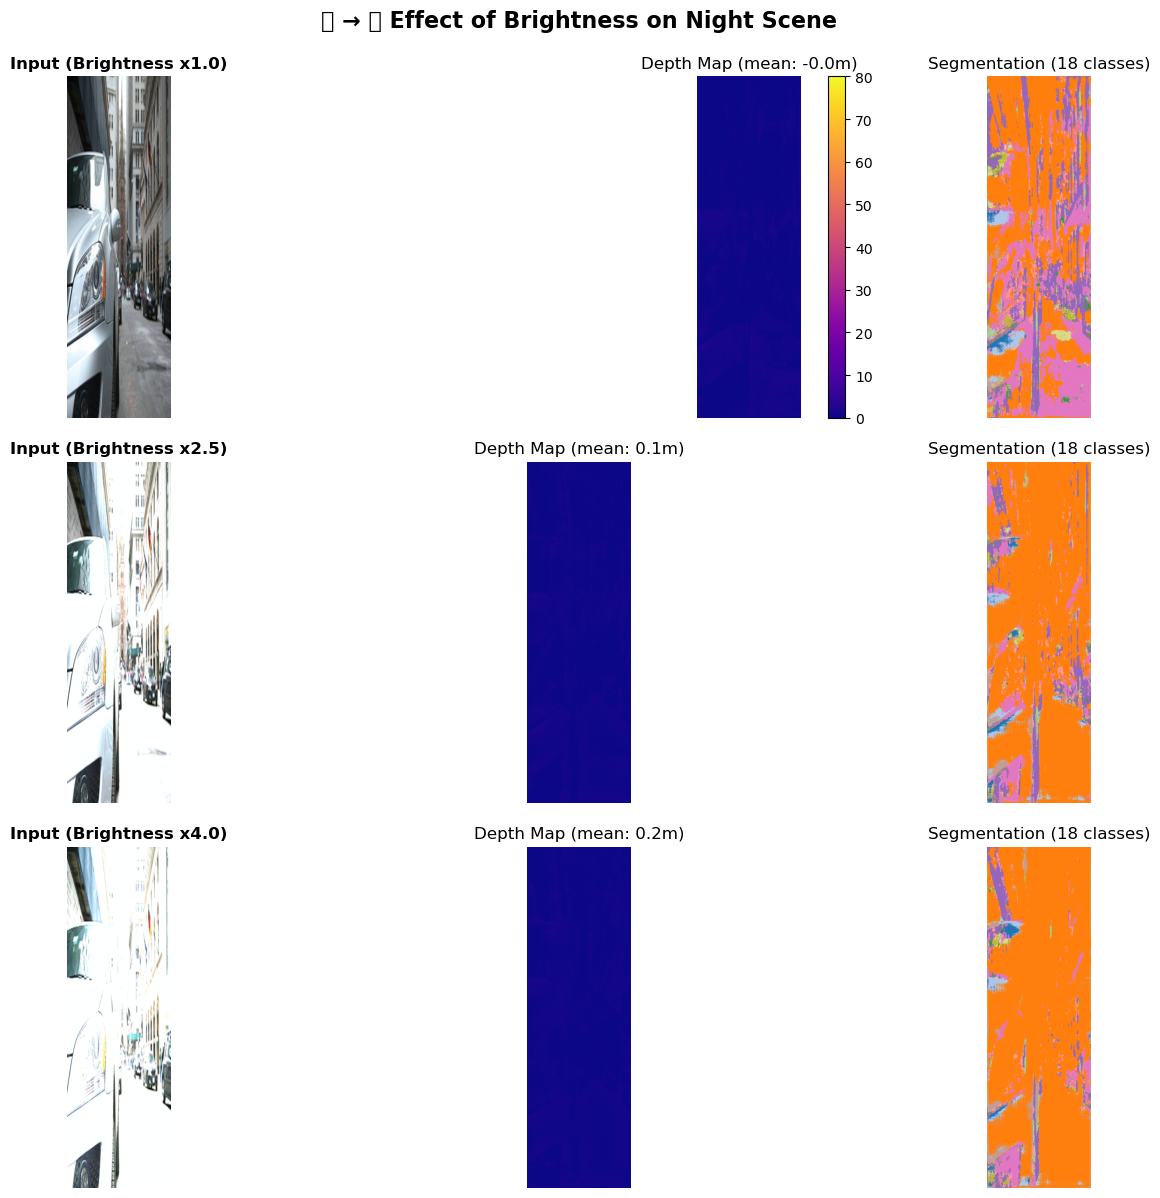


✅ SAVED: brightness_comparison.jpg

💡 CONCLUSION:
   If brightness helps → Your model is trained for daytime!
   Solution: Add brightness augmentation during training


In [16]:
import torch
from torchvision import transforms
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
import os
import numpy as np

def test_with_brightness_adjustment(image_path, device='cpu'):
    """Test model with artificially brightened night image"""
    
    print("🔄 Loading model...")
    model = MyModel(pretrained_encoder_path=None)
    
    if os.path.exists('depth_seg_model.pth'):
        model.load_state_dict(torch.load('depth_seg_model.pth', map_location=device))
        print("✅ Loaded trained weights!")
    else:
        print("❌ No trained weights found!")
        return
    
    model.to(device)
    model.eval()
    
    # Load and preprocess image
    img = Image.open(image_path).convert('RGB')
    
    # Create 3 versions: original, brightened, highly brightened
    brightness_factors = [1.0, 2.5, 4.0]
    versions = []
    
    for factor in brightness_factors:
        enhancer = ImageEnhance.Brightness(img)
        brightened_img = enhancer.enhance(factor)
        versions.append(brightened_img)
    
    # Transform
    transform = transforms.Compose([
        transforms.Resize((1056, 320)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    # Process all versions
    results = []
    with torch.no_grad():
        for idx, ver_img in enumerate(versions):
            img_tensor = transform(ver_img).unsqueeze(0).to(device)
            pred_depth, pred_seg_logits = model(img_tensor)
            
            pred_depth = pred_depth.cpu().squeeze().numpy()
            pred_seg = pred_seg_logits.argmax(dim=1).cpu().squeeze().numpy()
            
            # Denormalize for visualization
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img_np = img_tensor.squeeze(0).cpu()
            img_vis = (img_np * torch.tensor(std).view(3,1,1) + 
                      torch.tensor(mean).view(3,1,1)).clamp(0,1).permute(1,2,0).numpy()
            
            results.append({
                'img': img_vis,
                'depth': pred_depth,
                'seg': pred_seg,
                'factor': brightness_factors[idx]
            })
            
            print(f"\n📊 Brightness x{brightness_factors[idx]:.1f}:")
            print(f"   Depth: {pred_depth.min():.2f}m - {pred_depth.max():.2f}m (mean: {pred_depth.mean():.2f}m)")
            print(f"   Unique classes: {len(np.unique(pred_seg))}")
    
    # Visualize comparison
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    
    for idx, result in enumerate(results):
        # Input image
        axes[idx, 0].imshow(result['img'])
        axes[idx, 0].set_title(f"Input (Brightness x{result['factor']:.1f})", fontsize=12, fontweight='bold')
        axes[idx, 0].axis('off')
        
        # Depth
        im = axes[idx, 1].imshow(result['depth'], cmap='plasma', vmin=0, vmax=80)
        axes[idx, 1].set_title(f"Depth Map (mean: {result['depth'].mean():.1f}m)", fontsize=12)
        axes[idx, 1].axis('off')
        if idx == 0:
            plt.colorbar(im, ax=axes[idx, 1], fraction=0.046)
        
        # Segmentation
        axes[idx, 2].imshow(result['seg'], cmap='tab20', vmin=0, vmax=18)
        axes[idx, 2].set_title(f"Segmentation ({len(np.unique(result['seg']))} classes)", fontsize=12)
        axes[idx, 2].axis('off')
    
    plt.suptitle('🌙 → 🌞 Effect of Brightness on Night Scene', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('brightness_comparison.jpg', dpi=200, bbox_inches='tight')
    plt.show()
    
    print("\n✅ SAVED: brightness_comparison.jpg")
    print("\n💡 CONCLUSION:")
    print("   If brightness helps → Your model is trained for daytime!")
    print("   Solution: Add brightness augmentation during training")


# RUN TEST
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🚀 Device: {device}\n")

# Find the night traffic image
for ext in ['ph.png', 'ph.jpg', 'image.png', 'image.jpg']:
    if os.path.exists(ext):
        print(f"📸 Testing with: {ext}\n")
        test_with_brightness_adjustment(ext, device)
        break
else:
    print("❌ Need test image!")